# 作业1：Chinese-CLIP Zero-Shot 图像分类（中文）

## 原理
CLIP 同时训练了**图像编码器**和**文本编码器**，使两者在同一语义空间对齐。

Zero-Shot 分类流程：
1. 将候选类别写成中文文本 prompt（如 `"一只狗"`）
2. 分别计算图像 embedding 与每个文本 embedding 的**余弦相似度**
3. softmax 归一化后即为每个类别的置信概率

> `openai/clip-vit-base-patch32` 仅支持英文，中文标签会被 tokenizer 拆解为 `[UNK]`，效果很差。
> 本作业改用 **Chinese-CLIP**（`OFA-Sys/chinese-clip-vit-base-patch16`），专为中文图文对训练。

In [ ]:
# 安装依赖（首次运行）
%pip install transformers torch pillow -q

In [5]:
from PIL import Image
import torch
from transformers import ChineseCLIPModel, ChineseCLIPProcessor

print("依赖导入成功")

依赖导入成功


In [6]:
# ── 配置区（按需修改）──────────────────────────────────
IMAGE_PATH = "./dog.jpg"   # 替换为你本地小狗图片的实际路径

# Chinese-CLIP 直接使用中文标签
CANDIDATE_LABELS = [
    "一只狗",
    "一只猫",
    "一只鸟",
    "一匹马",
    "一个人",
    "一辆汽车",
    "一朵花",
]
# ────────────────────────────────────────────────────────

print(f"图片路径: {IMAGE_PATH}")
print(f"候选类别数: {len(CANDIDATE_LABELS)}")

图片路径: ./dog.jpg
候选类别数: 7


## 加载模型

使用 `OFA-Sys/chinese-clip-vit-base-patch16`，首次运行会自动从 HuggingFace 下载（约 400 MB）。
接口与 OpenAI CLIP 完全相同，只需换 `model_name` 即可。

In [7]:
model_name = "OFA-Sys/chinese-clip-vit-base-patch16"

print(f">>> 加载 Chinese-CLIP 模型: {model_name} ...")
model = ChineseCLIPModel.from_pretrained(model_name)
processor = ChineseCLIPProcessor.from_pretrained(model_name)
model.eval()
print("模型加载完成")

>>> 加载 Chinese-CLIP 模型: OFA-Sys/chinese-clip-vit-base-patch16 ...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


模型加载完成


## 加载图片并预览

图片尺寸: (600, 900)


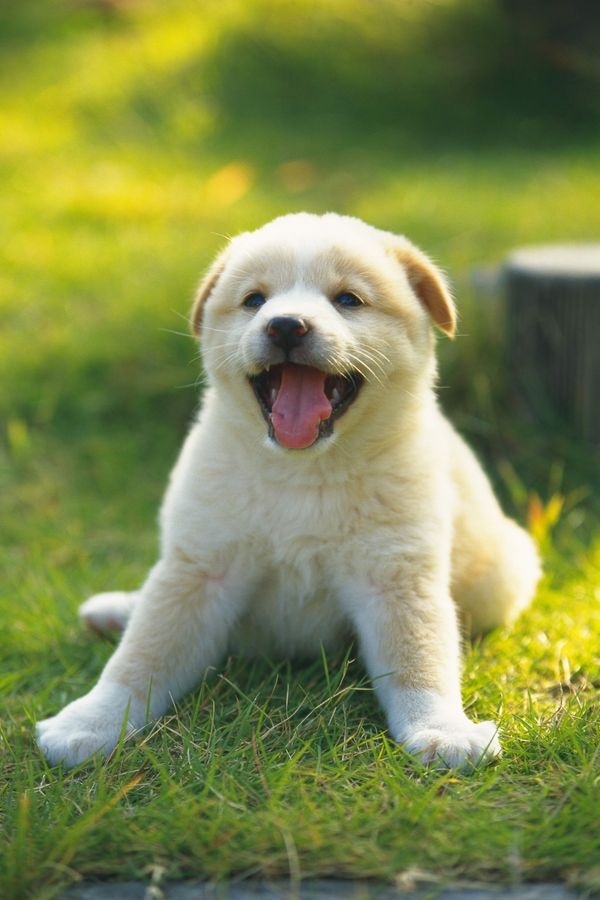

In [8]:
from IPython.display import display

image = Image.open(IMAGE_PATH).convert("RGB")
print(f"图片尺寸: {image.size}")
display(image)

## 推理：计算图文相似度

In [9]:
# 同时预处理图像 + 所有候选文本
inputs = processor(
    text=CANDIDATE_LABELS,
    images=image,
    return_tensors="pt",
    padding=True,
)

# 前向推理（不需要梯度）
with torch.no_grad():
    outputs = model(**inputs)

# logits_per_image shape: [1, num_labels]，已乘温度系数
logits = outputs.logits_per_image
probs = logits.softmax(dim=-1)[0]   # shape: [num_labels]

print("推理完成")

推理完成


## 结果展示

In [11]:
results = sorted(
    zip(CANDIDATE_LABELS, probs.tolist()),
    key=lambda x: x[1],
    reverse=True,
)

print("=== Zero-Shot 分类结果 ===")
for label, prob in results:
    bar = "█" * int(prob * 40)
    print(f"  {prob:.4f}  {bar:<40}  {label}")

top_label, top_prob = results[0]
print(f"\n>>> 预测类别: 【{top_label}】  置信度: {top_prob:.2%}")

=== Zero-Shot 分类结果 ===
  0.9870  ███████████████████████████████████████   一只狗
  0.0074                                            一只猫
  0.0031                                            一只鸟
  0.0013                                            一朵花
  0.0006                                            一个人
  0.0006                                            一匹马
  0.0000                                            一辆汽车

>>> 预测类别: 【一只狗】  置信度: 98.70%


## 可视化（可选）

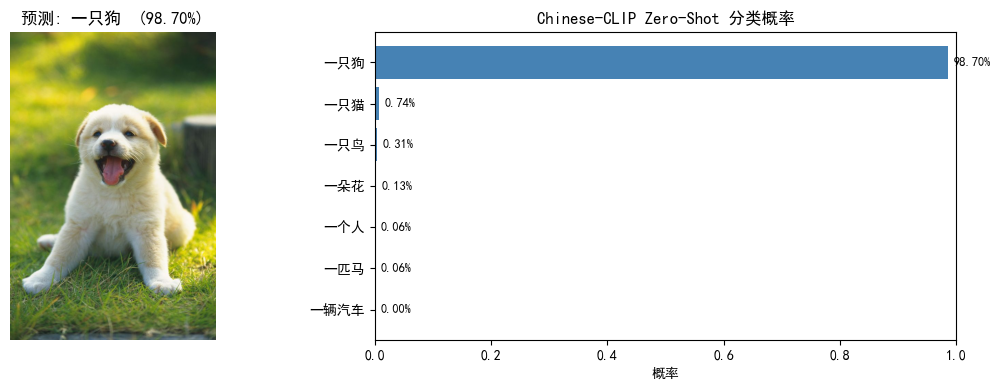

In [12]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

labels = [r[0] for r in results]   # 已是中文，直接使用
scores = [r[1] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：图片
axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title(f"预测: {labels[0]}  ({scores[0]:.2%})")

# 右：概率条形图
bars = axes[1].barh(labels[::-1], scores[::-1], color="steelblue")
axes[1].set_xlabel("概率")
axes[1].set_title("Chinese-CLIP Zero-Shot 分类概率")
axes[1].set_xlim(0, 1)
for bar, score in zip(bars, scores[::-1]):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{score:.2%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()